## AI Powered Banking Product Recommendation

In [ ]:
import os
import re
import uuid
from datetime import datetime

import fitz  # PyMuPDF
import pandas as pd
import numpy as np
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
import json

import joblib

In [250]:
#config path 
pdf_folder = r"C:\Users\HP\axis_ml\customer_statements"
OUTPUT_FOLDER = "data/output"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs("models", exist_ok=True)

In [251]:
TRANSACTION_CATEGORIES = {
    # Food & Dining
    'FOOD_DELIVERY': ['ZOMATO', 'SWIGGY', 'EATSURE', 'UBER EATS'],
    'RESTAURANTS': ['ANNAPOORNA', 'JUNIOR KUPPANNA', 'SREE ANNAPOORNA', 'HOTEL ANNAPOORNA',
                    'SHREE ANANDHAAS', 'KOVAI BIRIYANI', 'A2B ADYAR ANANDA BHAVAN'],
    'GROCERIES': ['DMART', 'MORE SUPERMARKET', 'SPAR HYPERMARKET', 'RELIANCE FRESH',
                  'NILGIRIS', 'PAZHAMUDIR NILAYAM', 'KOVAI PAZHAMUDIR'],

    # Shopping
    'ONLINE_SHOPPING': ['AMAZON', 'FLIPKART', 'MYNTRA', 'AJIO', 'MEESHO'],

    # Transportation
    'RIDE_HAILING': ['UBER', 'OLA', 'RAPIDO'],
    'FUEL': ['INDIAN OIL', 'BHARAT PETROLEUM', 'HP PETROL', 'SHELL'],

    # Bills & Utilities
    'ELECTRICITY': ['TANGEDCO'],
    'INTERNET': ['ACT FIBERNET', 'ACTBB'],
    'MOBILE_RECHARGE': ['AIRTEL RECHARGE', 'JIO RECHARGE', 'VI RECHARGE'],
    'GAS': ['INDANE GAS'],
    'RENT': ['RENT', 'LANDLORD'],

    # Healthcare
    'PHARMACY': ['MEDPLUS', 'NETMEDS', 'APOLLO PHARMACY'],
    'HEALTH_INSURANCE': ['HEALTH INSURANCE', 'PREMIUM'],

    # Entertainment & Subscriptions
    'STREAMING': ['NETFLIX', 'HOTSTAR', 'AMAZON PRIME'],
    'ENTERTAINMENT': ['BOOKMYSHOW'],

    # Financial
    'INVESTMENTS': ['AXISMUTUALFUND', 'SIP', 'MUTUAL FUND'],
    'CREDIT_CARD_PAYMENT': ['AXIS CREDIT CARD', 'CREDIT CARD', 'PAYMENT'],
    'SALARY': ['SALARY', 'PSG INDUSTRIES'],
    'BONUS': ['BONUS'],
    'INTEREST': ['INT/CREDIT', 'INTEREST'],

    # Transfers
    'FAMILY_SUPPORT': ['FAMILY SUPPORT'],
    'RECEIVED_MONEY': ['RECEIVED FROM', 'UPI/.*?/RECEIVED'],

    # Banking
    'ATM_WITHDRAWAL': ['ATM/CASH WDL', 'ATM WITHDRAWAL'],
    'BANK_CHARGES': ['CHG/', 'CHARGES', 'SMS ALERT'],
}

In [252]:
def categorize_transaction(description):
    description = description.upper()
    for category, keywords in TRANSACTION_CATEGORIES.items():
        for word in keywords:
            if word in description:
                return category
    return "OTHER"


#function  to safe search
def safe_search(pattern, text):
    match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
    return match.group(1).strip() if match else None

In [253]:
# pdf extraction
def extract_text_from_pdf(pdf_path):
    text = ""
    with fitz.open(pdf_path) as doc:
        for page in doc:
            text += page.get_text()
    return text

# parse account information

In [254]:
def parse_customer_info(text):

    return {

        "customer_id": safe_search(r"Customer ID:\s*(\w+)", text),

        "account_number": safe_search(r"Account Number:\s*(\d+)", text),

        "account_type": safe_search(r"Account Type:\s*(.*?)\s*IFSC", text),

        "branch_name": safe_search(r"Branch:\s*(.*?)\s*Statement Period", text),

        "ifsc_code": safe_search(r"IFSC Code:\s*(\w+)", text),

        "customer_category": "Regular",

        "account_open_date": None
    }

In [255]:
print("="*50)
print ("parse account summary")
print("="*50)

parse account summary


In [256]:
def parse_account_summary(text):

    start_date = safe_search(
        r"Statement Period:\s*(\d{2}-\w{3}-\d{4})", text
    )

    end_date = safe_search(
        r"to\s*(\d{2}-\w{3}-\d{4})", text
    )

    return {

        "opening_balance": safe_search(
            r"Opening\s*Balance.*?([\d,]+\.\d+)", text
        ),

        "total_credits": safe_search(
            r"Total\s*Credits.*?([\d,]+\.\d+)", text
        ),

        "total_debits": safe_search(
            r"Total\s*Debits.*?([\d,]+\.\d+)", text
        ),

        "closing_balance": safe_search(
            r"Closing\s*Balance.*?([\d,]+\.\d+)", text
        ),

        "statement_start_date": start_date,

        "statement_end_date": end_date
    }

In [257]:
print("="*50)
print ("parse transactions")
print("="*50)

parse transactions


In [258]:
def parse_transactions(text, account_id):

    pattern = re.compile(
        r"(\d{2}-\d{2}-\d{4})\s+(.+?)\s+(\w+\d+)\s+(DR|CR)\s+([\d,]+\.\d+)\s+([\d,]+\.\d+)"
    )

    rows = []

    for match in pattern.finditer(text):

        transaction_id = str(uuid.uuid4())

        date = match.group(1)
        description = match.group(2)
        txn_type = match.group(4)

        amount = float(match.group(5).replace(",",""))
        balance = float(match.group(6).replace(",",""))

        category = categorize_transaction(description)

        rows.append({

            "transaction_id": transaction_id,

            "account_id": account_id,

            "transaction_date": date,

            "transaction_description": description,

            "transaction_type": txn_type,

            "amount": amount,

            "balance_after_transaction": balance,

            "transaction_category": category
        })

    return rows

In [259]:
print("="*50)
print("extract all pdfs")
print("="*50)

extract all pdfs


In [260]:
customers = []
accounts = []
transactions = []

pdf_files = [f for f in os.listdir(pdf_folder) if f.endswith(".pdf")]

for file in tqdm(pdf_files):

    path = os.path.join(pdf_folder, file)

    text = extract_text_from_pdf(path)

    # ---------- Customer ----------
    customer = parse_customer_info(text)

    customer_id = customer["customer_id"]

    customers.append(customer)

    # ---------- Account ----------
    account_summary = parse_account_summary(text)

    account_id = str(uuid.uuid4())

    account_summary["account_id"] = account_id
    account_summary["customer_id"] = customer_id

    accounts.append(account_summary)

    # ---------- Transactions ----------
    txn_rows = parse_transactions(text, account_id)

    transactions.extend(txn_rows)

100%|██████████| 1000/1000 [04:53<00:00,  3.41it/s]


In [261]:
print("="*50)
print("dataframes and cleaning")
print("="*50)

dataframes and cleaning


In [262]:
#dataframes
customers_df = pd.DataFrame(customers)
accounts_df = pd.DataFrame(accounts)
transactions_df = pd.DataFrame(transactions)

In [263]:
accounts_df.head()

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_id,customer_id
0,"218,183.00","4,541,729.76","4,732,053.13","27,859.63",01-Jan-2021,23-Jan-2026,c28e023f-383a-43cd-a053-e235ed9ac36b,CIF00000001
1,"96,966.00","961,789.01","970,874.74","87,880.27",01-Jan-2021,23-Jan-2026,fc7e3f8b-cbe8-46d5-abc8-2318bac104d0,CIF00000002
2,"55,253.00","1,953,447.39","1,978,346.61","30,353.78",01-Jan-2021,23-Jan-2026,9acab0fc-c52b-431d-9a12-5c729e9b320c,CIF00000003
3,"182,406.00","3,025,475.44","2,146,990.98","1,060,890.46",01-Jan-2021,23-Jan-2026,d8f6bf3d-8488-443b-aae3-078fc40e6b6e,CIF00000004
4,"162,226.00","3,925,762.77","4,934,117.48","846,128.71",01-Jan-2021,23-Jan-2026,c6627424-25ad-4ef4-a91d-e41de2b0739d,CIF00000005


In [264]:
customers_df.head()

,customer_id,account_number,account_type,branch_name,ifsc_code,customer_category,account_open_date
0,CIF00000001,920000000001,Burgundy Savings,Coimbatore - Mettupalayam Road,UTIB0001385,Regular,None
1,CIF00000002,920000000002,Easy Access Savings,Coimbatore - Sungam,UTIB0001385,Regular,None
2,CIF00000003,920000000003,Easy Access Savings,Coimbatore - Trichy Road,UTIB0001385,Regular,None
3,CIF00000004,920000000004,Easy Access Savings,Coimbatore - Saravanampatti,UTIB0001385,Regular,None
4,CIF00000005,920000000005,Prime Savings,Coimbatore - Trichy Road,UTIB0001385,Regular,None


In [265]:
transactions_df.head()

,transaction_id,account_id,transaction_date,transaction_description,transaction_type,amount,balance_after_transaction,transaction_category
0,a36788d1-b18c-4451-b11e-d43e2a17d595,c28e023f-383a-43cd-a053-e235ed9ac36b,01-12-2022,UPI/973571737/LANDLORD RENT/landlord@okhdfc,DR,15139.0,203044.0,RENT
1,3a2bdcf8-1493-419c-a9f2-3f3155817cfe,c28e023f-383a-43cd-a053-e235ed9ac36b,01-12-2022,POS/988002/AMAZON INDIA/CARD **9369,DR,3603.0,199441.0,ONLINE_SHOPPING
2,02840ce1-14f9-40f6-a6fd-ce35f7b3e5fb,c28e023f-383a-43cd-a053-e235ed9ac36b,01-12-2022,UPI/957858928/RAPIDO/rapido@ybl,DR,135.0,199306.0,RIDE_HAILING
3,9326bed8-1124-4c71-810c-62fc7aaa38e8,c28e023f-383a-43cd-a053-e235ed9ac36b,03-12-2022,POS/214232/FLIPKART INDIA/CARD **9768,DR,1998.0,197308.0,ONLINE_SHOPPING
4,8cd0f56d-299a-453e-bbc3-0a1eff1e03bd,c28e023f-383a-43cd-a053-e235ed9ac36b,04-12-2022,UPI/233699231/EATSURE/eatsure@hdfcbank,DR,374.0,196934.0,FOOD_DELIVERY


In [266]:
##handling missing values customers_df
customers_df.isnull().sum()

customer_id             4
account_number          0
account_type            0
branch_name             0
ifsc_code               0
customer_category       0
account_open_date    1000
dtype: int64

In [267]:
##fill null values
customers_df["customer_id"] = customers_df["customer_id"].fillna(
    "CIF" + customers_df["account_number"].astype(str).str[-8:]
)

In [268]:
customers_df.duplicated().sum()

np.int64(0)

In [269]:
customers_df.describe()

,customer_id,account_number,account_type,branch_name,ifsc_code,customer_category,account_open_date
count,1000,1000,1000,1000,1000,1000,0
unique,1000,1000,3,18,1,1,0
top,CIF00000001,920000000001,Burgundy Savings,Coimbatore - Vadavalli,UTIB0001385,Regular,NaN
freq,1,1,336,71,1000,1000,NaN


In [270]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        1000 non-null   str   
 1   account_number     1000 non-null   str   
 2   account_type       1000 non-null   str   
 3   branch_name        1000 non-null   str   
 4   ifsc_code          1000 non-null   str   
 5   customer_category  1000 non-null   str   
 6   account_open_date  0 non-null      object
dtypes: object(1), str(6)
memory usage: 54.8+ KB


In [271]:
customers_df["account_type"] = customers_df["account_type"].astype("category")
customers_df["branch_name"] = customers_df["branch_name"].astype("category")
customers_df["customer_category"] = customers_df["customer_category"].astype("category")

In [272]:
customers_df.dtypes

customer_id               str
account_number            str
account_type         category
branch_name          category
ifsc_code                 str
customer_category    category
account_open_date      object
dtype: object

In [273]:
customers_df.head(5)

,customer_id,account_number,account_type,branch_name,ifsc_code,customer_category,account_open_date
0,CIF00000001,920000000001,Burgundy Savings,Coimbatore - Mettupalayam Road,UTIB0001385,Regular,None
1,CIF00000002,920000000002,Easy Access Savings,Coimbatore - Sungam,UTIB0001385,Regular,None
2,CIF00000003,920000000003,Easy Access Savings,Coimbatore - Trichy Road,UTIB0001385,Regular,None
3,CIF00000004,920000000004,Easy Access Savings,Coimbatore - Saravanampatti,UTIB0001385,Regular,None
4,CIF00000005,920000000005,Prime Savings,Coimbatore - Trichy Road,UTIB0001385,Regular,None


In [274]:
print("="*50)
print("accounts_df")
print("="*50)


accounts_df


In [275]:
accounts_df.head()

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_id,customer_id
0,"218,183.00","4,541,729.76","4,732,053.13","27,859.63",01-Jan-2021,23-Jan-2026,c28e023f-383a-43cd-a053-e235ed9ac36b,CIF00000001
1,"96,966.00","961,789.01","970,874.74","87,880.27",01-Jan-2021,23-Jan-2026,fc7e3f8b-cbe8-46d5-abc8-2318bac104d0,CIF00000002
2,"55,253.00","1,953,447.39","1,978,346.61","30,353.78",01-Jan-2021,23-Jan-2026,9acab0fc-c52b-431d-9a12-5c729e9b320c,CIF00000003
3,"182,406.00","3,025,475.44","2,146,990.98","1,060,890.46",01-Jan-2021,23-Jan-2026,d8f6bf3d-8488-443b-aae3-078fc40e6b6e,CIF00000004
4,"162,226.00","3,925,762.77","4,934,117.48","846,128.71",01-Jan-2021,23-Jan-2026,c6627424-25ad-4ef4-a91d-e41de2b0739d,CIF00000005


In [276]:
accounts_df.tail()

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_id,customer_id
995,"158,605.00","3,598,227.56","3,552,385.99","204,446.57",01-Jan-2021,23-Jan-2026,d9e78a48-9bc0-4d3c-90fd-33479f87a670,CIF00000996
996,"130,305.00","3,863,064.84","2,878,630.68","1,114,739.16",01-Jan-2021,23-Jan-2026,163187b4-36d4-4589-aa6e-48d12d6a9dbc,CIF00000997
997,"93,780.00","3,604,770.15","4,204,755.03","506,204.88",01-Jan-2021,23-Jan-2026,fa8f3a65-a80d-4710-8ce4-d968409bfee1,CIF00000998
998,"44,782.00","3,550,818.89","2,706,642.81","888,958.08",01-Jan-2021,23-Jan-2026,50b42b99-e3a2-493f-b968-d2bc07ed932e,CIF00000999
999,"390,657.00","11,239,673.30","2,965,645.37","8,664,684.93",01-Jan-2021,23-Jan-2026,025106b1-20fd-4483-b309-fcac1d4679d3,CIF00001000


In [277]:
accounts_df.isnull().sum()

opening_balance         0
total_credits           0
total_debits            0
closing_balance         0
statement_start_date    0
statement_end_date      0
account_id              0
customer_id             4
dtype: int64

In [278]:
accounts_df[accounts_df["customer_id"].isnull()]

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_id,customer_id
64,"287,181.00","2,697,648.61","2,163,370.50","821,459.11",01-Jan-2021,23-Jan-2026,cce7159a-554b-4bef-844d-e2d7ec74cdaf,NaN
84,"105,870.00","3,719,054.75","3,451,957.73","372,967.02",01-Jan-2021,23-Jan-2026,cb017a7f-546d-4439-964a-02c03ba24fb3,NaN
360,"341,990.00","9,981,571.59","4,931,426.28","5,392,135.31",01-Jan-2021,23-Jan-2026,b6394ee8-81f2-41ec-9bfc-81c2951cfc8e,NaN
602,"84,958.00","3,576,191.58","3,604,272.83","56,876.75",01-Jan-2021,23-Jan-2026,30747608-79cf-42ab-9f2c-7da60c21a2d5,NaN


In [279]:
# Fix null customer_id in accounts_df using positional alignment
accounts_df["customer_id"] = accounts_df["customer_id"].fillna(
    customers_df["customer_id"]
)

In [280]:
# Verify
print(accounts_df["customer_id"].isnull().sum())

0


In [281]:
print(accounts_df[accounts_df.index.isin([64, 84, 360, 602])][["account_id", "customer_id"]])

                               account_id  customer_id
64   cce7159a-554b-4bef-844d-e2d7ec74cdaf  CIF00000065
84   cb017a7f-546d-4439-964a-02c03ba24fb3  CIF00000085
360  b6394ee8-81f2-41ec-9bfc-81c2951cfc8e  CIF00000361
602  30747608-79cf-42ab-9f2c-7da60c21a2d5  CIF00000603


In [282]:
accounts_df.duplicated().sum()

np.int64(0)

In [283]:
accounts_df.describe()

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_id,customer_id
count,1000,1000,1000,1000,1000,1000,1000,1000
unique,999,1000,1000,1000,1,1,1000,1000
top,"271,062.00","4,541,729.76","4,732,053.13","27,859.63",01-Jan-2021,23-Jan-2026,c28e023f-383a-43cd-a053-e235ed9ac36b,CIF00000001
freq,2,1,1,1,1000,1000,1,1


In [284]:
accounts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   opening_balance       1000 non-null   str  
 1   total_credits         1000 non-null   str  
 2   total_debits          1000 non-null   str  
 3   closing_balance       1000 non-null   str  
 4   statement_start_date  1000 non-null   str  
 5   statement_end_date    1000 non-null   str  
 6   account_id            1000 non-null   str  
 7   customer_id           1000 non-null   str  
dtypes: str(8)
memory usage: 62.6 KB


In [285]:
#Fix balance columns (remove commas → convert to float)
balance_cols = ["opening_balance", "total_credits", "total_debits", "closing_balance"]

for col in balance_cols:
    accounts_df[col] = accounts_df[col].str.replace(",", "").astype(float)

In [286]:
# Fix date columns

accounts_df["statement_end_date"] = pd.to_datetime(
    accounts_df["statement_end_date"], format="%d-%b-%Y"
)
accounts_df["statement_start_date"] = pd.to_datetime(
    accounts_df["statement_start_date"], format="%d-%b-%Y"
)

In [287]:
print(accounts_df.dtypes)


opening_balance                float64
total_credits                  float64
total_debits                   float64
closing_balance                float64
statement_start_date    datetime64[us]
statement_end_date      datetime64[us]
account_id                         str
customer_id                        str
dtype: object


In [288]:
accounts_df.head()

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_id,customer_id
0,218183.0,4541729.76,4732053.13,27859.63,2021-01-01,2026-01-23,c28e023f-383a-43cd-a053-e235ed9ac36b,CIF00000001
1,96966.0,961789.01,970874.74,87880.27,2021-01-01,2026-01-23,fc7e3f8b-cbe8-46d5-abc8-2318bac104d0,CIF00000002
2,55253.0,1953447.39,1978346.61,30353.78,2021-01-01,2026-01-23,9acab0fc-c52b-431d-9a12-5c729e9b320c,CIF00000003
3,182406.0,3025475.44,2146990.98,1060890.46,2021-01-01,2026-01-23,d8f6bf3d-8488-443b-aae3-078fc40e6b6e,CIF00000004
4,162226.0,3925762.77,4934117.48,846128.71,2021-01-01,2026-01-23,c6627424-25ad-4ef4-a91d-e41de2b0739d,CIF00000005


In [289]:
print(accounts_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   opening_balance       1000 non-null   float64       
 1   total_credits         1000 non-null   float64       
 2   total_debits          1000 non-null   float64       
 3   closing_balance       1000 non-null   float64       
 4   statement_start_date  1000 non-null   datetime64[us]
 5   statement_end_date    1000 non-null   datetime64[us]
 6   account_id            1000 non-null   str           
 7   customer_id           1000 non-null   str           
dtypes: datetime64[us](2), float64(4), str(2)
memory usage: 62.6 KB
None


In [290]:
print("="*50)
print("transactions_df")
print("="*50)

transactions_df


In [291]:
transactions_df.head()

,transaction_id,account_id,transaction_date,transaction_description,transaction_type,amount,balance_after_transaction,transaction_category
0,a36788d1-b18c-4451-b11e-d43e2a17d595,c28e023f-383a-43cd-a053-e235ed9ac36b,01-12-2022,UPI/973571737/LANDLORD RENT/landlord@okhdfc,DR,15139.0,203044.0,RENT
1,3a2bdcf8-1493-419c-a9f2-3f3155817cfe,c28e023f-383a-43cd-a053-e235ed9ac36b,01-12-2022,POS/988002/AMAZON INDIA/CARD **9369,DR,3603.0,199441.0,ONLINE_SHOPPING
2,02840ce1-14f9-40f6-a6fd-ce35f7b3e5fb,c28e023f-383a-43cd-a053-e235ed9ac36b,01-12-2022,UPI/957858928/RAPIDO/rapido@ybl,DR,135.0,199306.0,RIDE_HAILING
3,9326bed8-1124-4c71-810c-62fc7aaa38e8,c28e023f-383a-43cd-a053-e235ed9ac36b,03-12-2022,POS/214232/FLIPKART INDIA/CARD **9768,DR,1998.0,197308.0,ONLINE_SHOPPING
4,8cd0f56d-299a-453e-bbc3-0a1eff1e03bd,c28e023f-383a-43cd-a053-e235ed9ac36b,04-12-2022,UPI/233699231/EATSURE/eatsure@hdfcbank,DR,374.0,196934.0,FOOD_DELIVERY


In [292]:
transactions_df.isnull().sum()

transaction_id               0
account_id                   0
transaction_date             0
transaction_description      0
transaction_type             0
amount                       0
balance_after_transaction    0
transaction_category         0
dtype: int64

In [293]:
transactions_df.duplicated().sum()

np.int64(0)

In [294]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044393 entries, 0 to 1044392
Data columns (total 8 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   transaction_id             1044393 non-null  str    
 1   account_id                 1044393 non-null  str    
 2   transaction_date           1044393 non-null  str    
 3   transaction_description    1044393 non-null  str    
 4   transaction_type           1044393 non-null  str    
 5   amount                     1044393 non-null  float64
 6   balance_after_transaction  1044393 non-null  float64
 7   transaction_category       1044393 non-null  str    
dtypes: float64(2), str(6)
memory usage: 63.7 MB


In [295]:
# Convert date
transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"],
    format="%d-%m-%Y"
)

In [296]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044393 entries, 0 to 1044392
Data columns (total 8 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   transaction_id             1044393 non-null  str           
 1   account_id                 1044393 non-null  str           
 2   transaction_date           1044393 non-null  datetime64[us]
 3   transaction_description    1044393 non-null  str           
 4   transaction_type           1044393 non-null  str           
 5   amount                     1044393 non-null  float64       
 6   balance_after_transaction  1044393 non-null  float64       
 7   transaction_category       1044393 non-null  str           
dtypes: datetime64[us](1), float64(2), str(5)
memory usage: 63.7 MB


In [297]:
transactions_df.head()

,transaction_id,account_id,transaction_date,transaction_description,transaction_type,amount,balance_after_transaction,transaction_category
0,a36788d1-b18c-4451-b11e-d43e2a17d595,c28e023f-383a-43cd-a053-e235ed9ac36b,2022-12-01,UPI/973571737/LANDLORD RENT/landlord@okhdfc,DR,15139.0,203044.0,RENT
1,3a2bdcf8-1493-419c-a9f2-3f3155817cfe,c28e023f-383a-43cd-a053-e235ed9ac36b,2022-12-01,POS/988002/AMAZON INDIA/CARD **9369,DR,3603.0,199441.0,ONLINE_SHOPPING
2,02840ce1-14f9-40f6-a6fd-ce35f7b3e5fb,c28e023f-383a-43cd-a053-e235ed9ac36b,2022-12-01,UPI/957858928/RAPIDO/rapido@ybl,DR,135.0,199306.0,RIDE_HAILING
3,9326bed8-1124-4c71-810c-62fc7aaa38e8,c28e023f-383a-43cd-a053-e235ed9ac36b,2022-12-03,POS/214232/FLIPKART INDIA/CARD **9768,DR,1998.0,197308.0,ONLINE_SHOPPING
4,8cd0f56d-299a-453e-bbc3-0a1eff1e03bd,c28e023f-383a-43cd-a053-e235ed9ac36b,2022-12-04,UPI/233699231/EATSURE/eatsure@hdfcbank,DR,374.0,196934.0,FOOD_DELIVERY


In [298]:
print("*"*100)
print("fix customers_df null values ")
print("*"*100)

****************************************************************************************************
fix customers_df null values 
****************************************************************************************************


In [299]:

# Find earliest transaction
account_open_dates = (
    transactions_df
    .groupby("account_id")["transaction_date"]
    .min()
    .reset_index()
)

account_open_dates.rename(
    columns={"transaction_date": "account_open_date"},
    inplace=True
)

# Merge with accounts
accounts_df = accounts_df.merge(
    account_open_dates,
    on="account_id",
    how="left"
)

# Remove old column
customers_df.drop(columns=["account_open_date"], inplace=True)

# Merge with customers
customers_df = customers_df.merge(
    accounts_df[["customer_id", "account_open_date"]],
    on="customer_id",
    how="left"
)

In [300]:
customers_df.head()

,customer_id,account_number,account_type,branch_name,ifsc_code,customer_category,account_open_date
0,CIF00000001,920000000001,Burgundy Savings,Coimbatore - Mettupalayam Road,UTIB0001385,Regular,2022-12-01
1,CIF00000002,920000000002,Easy Access Savings,Coimbatore - Sungam,UTIB0001385,Regular,2025-01-02
2,CIF00000003,920000000003,Easy Access Savings,Coimbatore - Trichy Road,UTIB0001385,Regular,2024-11-01
3,CIF00000004,920000000004,Easy Access Savings,Coimbatore - Saravanampatti,UTIB0001385,Regular,2023-09-01
4,CIF00000005,920000000005,Prime Savings,Coimbatore - Trichy Road,UTIB0001385,Regular,2022-09-01


In [301]:
customers_df.describe()

,account_open_date
count,1000
mean,2023-04-07 22:17:45.600000
min,2021-01-01 00:00:00
25%,2022-03-01 00:00:00
50%,2023-04-01 00:00:00
75%,2024-06-01 00:00:00
max,2025-08-04 00:00:00


In [302]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        1000 non-null   str           
 1   account_number     1000 non-null   str           
 2   account_type       1000 non-null   category      
 3   branch_name        1000 non-null   category      
 4   ifsc_code          1000 non-null   str           
 5   customer_category  1000 non-null   category      
 6   account_open_date  1000 non-null   datetime64[us]
dtypes: category(3), datetime64[us](1), str(3)
memory usage: 34.5 KB


In [303]:
accounts_df.head()

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_id,customer_id,account_open_date
0,218183.0,4541729.76,4732053.13,27859.63,2021-01-01,2026-01-23,c28e023f-383a-43cd-a053-e235ed9ac36b,CIF00000001,2022-12-01
1,96966.0,961789.01,970874.74,87880.27,2021-01-01,2026-01-23,fc7e3f8b-cbe8-46d5-abc8-2318bac104d0,CIF00000002,2025-01-02
2,55253.0,1953447.39,1978346.61,30353.78,2021-01-01,2026-01-23,9acab0fc-c52b-431d-9a12-5c729e9b320c,CIF00000003,2024-11-01
3,182406.0,3025475.44,2146990.98,1060890.46,2021-01-01,2026-01-23,d8f6bf3d-8488-443b-aae3-078fc40e6b6e,CIF00000004,2023-09-01
4,162226.0,3925762.77,4934117.48,846128.71,2021-01-01,2026-01-23,c6627424-25ad-4ef4-a91d-e41de2b0739d,CIF00000005,2022-09-01


In [304]:
accounts_df.describe()

,opening_balance,total_credits,total_debits,closing_balance,statement_start_date,statement_end_date,account_open_date
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000,1000,1000
mean,2.247362e+05,6.044653e+06,4.085903e+06,2.463776e+06,2021-01-01 00:00:00,2026-01-23 00:00:00,2023-04-07 22:17:45.600000
min,2.043600e+04,3.737456e+05,3.190520e+05,2.714000e+01,2021-01-01 00:00:00,2026-01-23 00:00:00,2021-01-01 00:00:00
25%,1.027435e+05,2.775885e+06,2.163497e+06,5.511518e+05,2021-01-01 00:00:00,2026-01-23 00:00:00,2022-03-01 00:00:00
50%,1.759955e+05,4.667818e+06,3.614331e+06,1.416701e+06,2021-01-01 00:00:00,2026-01-23 00:00:00,2023-04-01 00:00:00
75%,2.946030e+05,7.832884e+06,5.340030e+06,3.152290e+06,2021-01-01 00:00:00,2026-01-23 00:00:00,2024-06-01 00:00:00
max,1.085913e+06,3.139716e+07,1.909144e+07,2.089333e+07,2021-01-01 00:00:00,2026-01-23 00:00:00,2025-08-04 00:00:00
std,1.750117e+05,4.772740e+06,2.621840e+06,2.891076e+06,NaN,NaN,NaN


In [305]:
accounts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   opening_balance       1000 non-null   float64       
 1   total_credits         1000 non-null   float64       
 2   total_debits          1000 non-null   float64       
 3   closing_balance       1000 non-null   float64       
 4   statement_start_date  1000 non-null   datetime64[us]
 5   statement_end_date    1000 non-null   datetime64[us]
 6   account_id            1000 non-null   str           
 7   customer_id           1000 non-null   str           
 8   account_open_date     1000 non-null   datetime64[us]
dtypes: datetime64[us](3), float64(4), str(2)
memory usage: 70.4 KB


In [306]:
transactions_df.head()

,transaction_id,account_id,transaction_date,transaction_description,transaction_type,amount,balance_after_transaction,transaction_category
0,a36788d1-b18c-4451-b11e-d43e2a17d595,c28e023f-383a-43cd-a053-e235ed9ac36b,2022-12-01,UPI/973571737/LANDLORD RENT/landlord@okhdfc,DR,15139.0,203044.0,RENT
1,3a2bdcf8-1493-419c-a9f2-3f3155817cfe,c28e023f-383a-43cd-a053-e235ed9ac36b,2022-12-01,POS/988002/AMAZON INDIA/CARD **9369,DR,3603.0,199441.0,ONLINE_SHOPPING
2,02840ce1-14f9-40f6-a6fd-ce35f7b3e5fb,c28e023f-383a-43cd-a053-e235ed9ac36b,2022-12-01,UPI/957858928/RAPIDO/rapido@ybl,DR,135.0,199306.0,RIDE_HAILING
3,9326bed8-1124-4c71-810c-62fc7aaa38e8,c28e023f-383a-43cd-a053-e235ed9ac36b,2022-12-03,POS/214232/FLIPKART INDIA/CARD **9768,DR,1998.0,197308.0,ONLINE_SHOPPING
4,8cd0f56d-299a-453e-bbc3-0a1eff1e03bd,c28e023f-383a-43cd-a053-e235ed9ac36b,2022-12-04,UPI/233699231/EATSURE/eatsure@hdfcbank,DR,374.0,196934.0,FOOD_DELIVERY


In [307]:
transactions_df.describe()

,transaction_date,amount,balance_after_transaction
count,1044393,1.044393e+06,1.044393e+06
mean,2024-05-20 20:01:36.005239,8.292456e+03,1.625261e+06
min,2021-01-01 00:00:00,1.770000e+01,2.000000e+00
25%,2023-07-19 00:00:00,4.000000e+02,3.016984e+05
50%,2024-08-09 00:00:00,9.970000e+02,8.369854e+05
75%,2025-05-26 00:00:00,2.635000e+03,2.099075e+06
max,2026-02-01 00:00:00,7.241518e+05,2.089434e+07
std,NaN,3.541793e+04,2.073344e+06


In [308]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044393 entries, 0 to 1044392
Data columns (total 8 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   transaction_id             1044393 non-null  str           
 1   account_id                 1044393 non-null  str           
 2   transaction_date           1044393 non-null  datetime64[us]
 3   transaction_description    1044393 non-null  str           
 4   transaction_type           1044393 non-null  str           
 5   amount                     1044393 non-null  float64       
 6   balance_after_transaction  1044393 non-null  float64       
 7   transaction_category       1044393 non-null  str           
dtypes: datetime64[us](1), float64(2), str(5)
memory usage: 63.7 MB


In [309]:
print("="*50)
print("outliers handling")
print("="*50)

outliers handling


In [310]:

#identify numeric columns
accounts_df.select_dtypes(include=['float64','int64']).columns

Index(['opening_balance', 'total_credits', 'total_debits', 'closing_balance'], dtype='str')

In [311]:
transactions_df.select_dtypes(include=['float64','int64']).columns

Index(['amount', 'balance_after_transaction'], dtype='str')

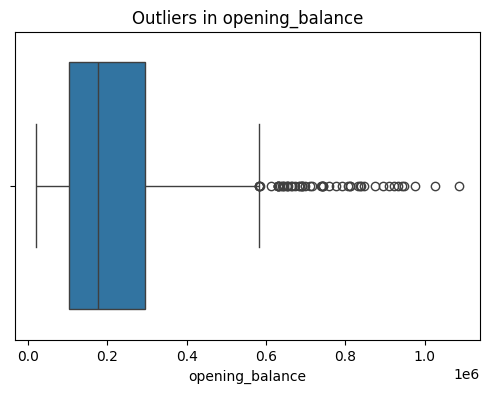

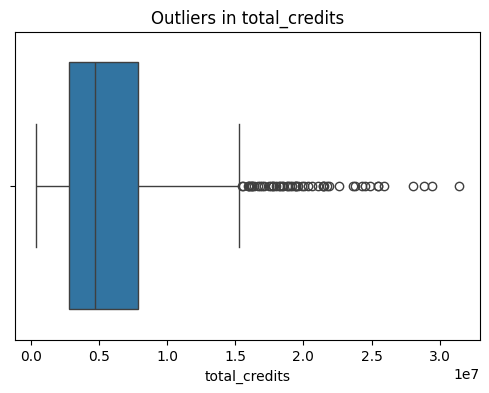

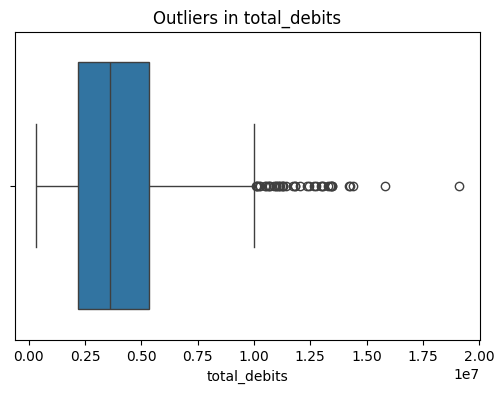

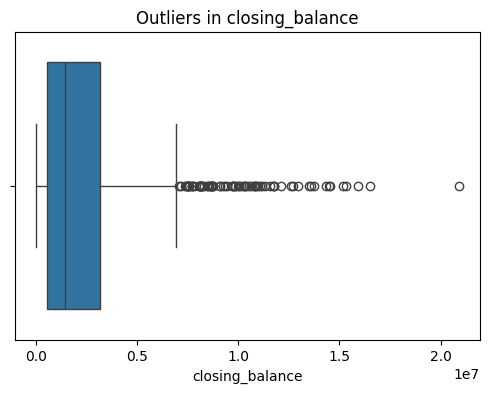

In [312]:
numeric_cols = ['opening_balance','total_credits','total_debits','closing_balance']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=accounts_df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

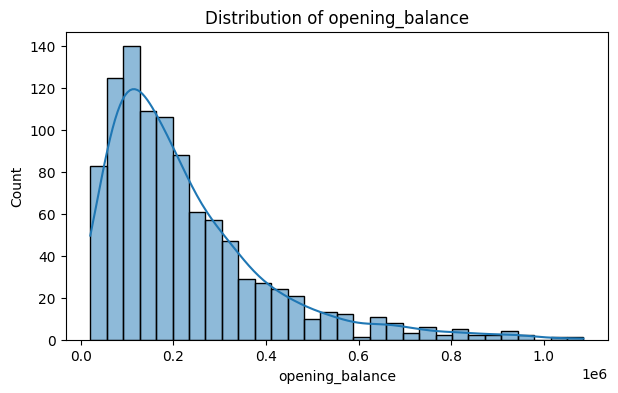

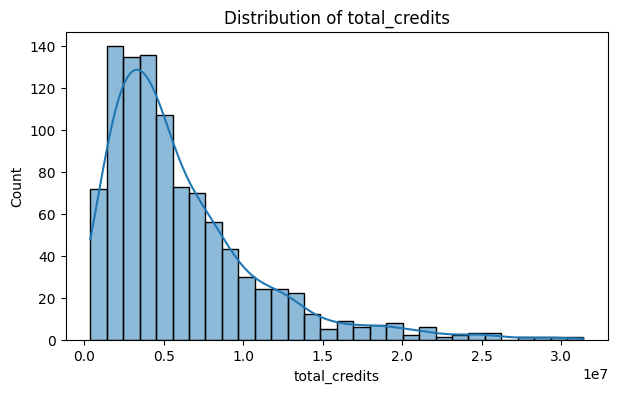

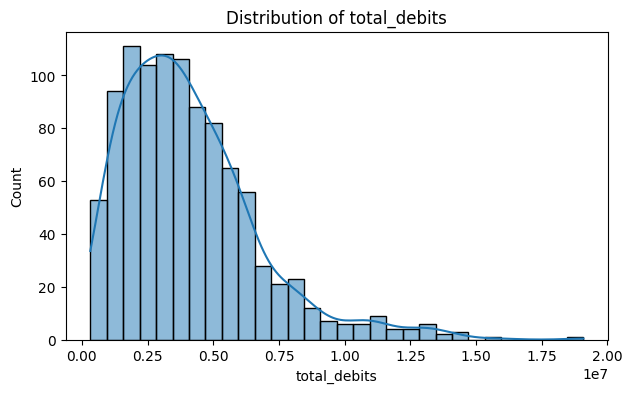

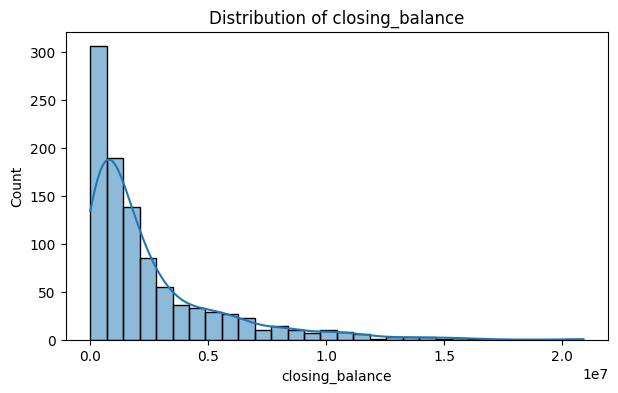

In [313]:
#distribution
cols = [
    "opening_balance",
    "total_credits",
    "total_debits",
    "closing_balance"
]

for col in cols:
    
    plt.figure(figsize=(7,4))
    
    sns.histplot(accounts_df[col], bins=30, kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

In [314]:
print("=" * 60)
print("BEFORE OUTLIER TREATMENT")
print("=" * 60)

BEFORE OUTLIER TREATMENT


In [315]:
print("\naccounts_df:")
print(accounts_df[['opening_balance', 'total_credits',
                    'total_debits', 'closing_balance']].describe().round(2))


accounts_df:
       opening_balance  total_credits  total_debits  closing_balance
count          1000.00        1000.00       1000.00          1000.00
mean         224736.25     6044652.72    4085903.48       2463776.29
std          175011.69     4772740.45    2621839.72       2891076.09
min           20436.00      373745.62     319052.03            27.14
25%          102743.50     2775885.41    2163496.99        551151.76
50%          175995.50     4667817.86    3614330.71       1416701.48
75%          294603.00     7832884.12    5340029.64       3152289.92
max         1085913.00    31397155.38   19091438.69      20893326.47


In [316]:
print("\ntransactions_df:")
print(transactions_df[['amount']].describe().round(2))


transactions_df:
           amount
count  1044393.00
mean      8292.46
std      35417.93
min         17.70
25%        400.00
50%        997.00
75%       2635.00
max     724151.75


In [317]:
print("="*50)
print("method functions")
print("="*50)   

method functions


In [318]:
def cap_percentile(df, column, lower_pct=0.01, upper_pct=0.99):
    lower = df[column].quantile(lower_pct)
    upper = df[column].quantile(upper_pct)
    df[column] = df[column].clip(lower=lower, upper=upper)
    return df


def cap_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower, upper=upper)
    return df

In [319]:
print("\n" + "=" * 60)
print("apply outlier treatment")
print("=" * 60)


apply outlier treatment


In [320]:
# opening_balance → Percentile
before = accounts_df['opening_balance'].max()
accounts_df = cap_percentile(accounts_df, 'opening_balance')
print(f"\n opening_balance")
print(f"   max before: {before:,.0f}  -  max after: {accounts_df['opening_balance'].max():,.0f}")


 opening_balance
   max before: 1,085,913  -  max after: 848,214


In [321]:
# total_credits → Percentile
before = accounts_df['total_credits'].max()
accounts_df = cap_percentile(accounts_df, 'total_credits')
print(f"\n total_credits")
print(f"   max before: {before:,.0f} - max after: {accounts_df['total_credits'].max():,.0f}")


 total_credits
   max before: 31,397,155 - max after: 23,761,836


In [322]:
# total_debits → IQR
before = accounts_df['total_debits'].max()
accounts_df = cap_iqr(accounts_df, 'total_debits')
print(f"\n total_debits")
print(f"   max before: {before:,.0f} - max after: {accounts_df['total_debits'].max():,.0f}")


 total_debits
   max before: 19,091,439 - max after: 10,104,829


In [323]:
# closing_balance → Percentile
before = accounts_df['closing_balance'].max()
accounts_df = cap_percentile(accounts_df, 'closing_balance')
print(f"\n closing_balance")
print(f"   max before: {before:,.0f} - max after: {accounts_df['closing_balance'].max():,.0f}")


 closing_balance
   max before: 20,893,326 - max after: 13,482,777


In [324]:
before = transactions_df['amount'].max()

transactions_df = cap_percentile(
    transactions_df,
    'amount',
    lower_pct=0.005,   # 0.5%
    upper_pct=0.995    # 99.5%
)

print(f"\n amount")
print(f"   max before: {before:,.0f} - max after: {transactions_df['amount'].max():,.0f}")


 amount
   max before: 724,152 - max after: 265,399


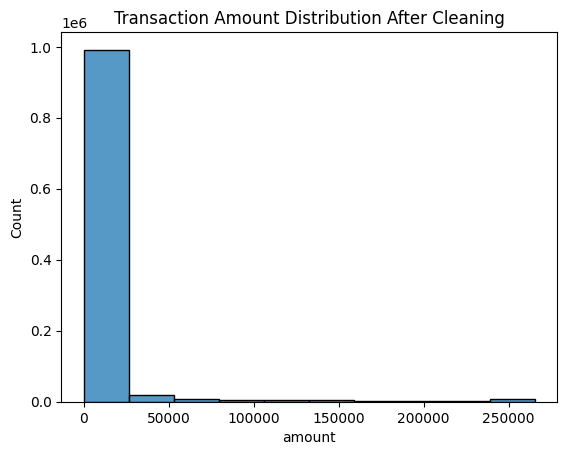

In [325]:
sns.histplot(transactions_df['amount'], bins=10)
plt.title("Transaction Amount Distribution After Cleaning")
plt.show()

In [326]:
print("\n" + "=" * 60)
print("LOG TRANSFORM (on skewed columns)")
print("=" * 60)


LOG TRANSFORM (on skewed columns)


In [327]:
print("\n" + "=" * 60)
print("AFTER OUTLIER TREATMENT")
print("=" * 60)


AFTER OUTLIER TREATMENT


In [328]:
print("\naccounts_df:")
print(accounts_df[['opening_balance', 'total_credits',
                   'total_debits', 'closing_balance']].describe().round(2))

print("\ntransactions_df:")
print(transactions_df[['amount']].describe().round(2))


accounts_df:
       opening_balance  total_credits  total_debits  closing_balance
count          1000.00        1000.00       1000.00          1000.00
mean         223740.38     6015193.45    4003412.90       2444206.66
std          170821.98     4639546.30    2361846.93       2800792.02
min           29225.13      643507.51     319052.03         19627.16
25%          102743.50     2775885.41    2163496.99        551151.76
50%          175995.50     4667817.86    3614330.71       1416701.48
75%          294603.00     7832884.12    5340029.64       3152289.92
max          848213.67    23761835.79   10104828.61      13482777.20

transactions_df:
           amount
count  1044393.00
mean      7783.02
std      30103.14
min         17.70
25%        400.00
50%        997.00
75%       2635.00
max     265398.79


# Feature engineering 

In [329]:
accounts_df['avg_balance'] = (
    accounts_df['opening_balance'] + accounts_df['closing_balance']
) / 2

In [330]:
#transactions merge 
txn = transactions_df.merge(
    accounts_df[['account_id', 'customer_id']],
    on='account_id',
    how='left'
)

txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])
txn['transaction_description'] = txn['transaction_description'].str.upper()

In [331]:
#time period 
months = (
    (txn["transaction_date"].max() - txn["transaction_date"].min()).days
) / 30

months = round(months, 2)
print("Months:", months)

Months: 61.9


In [332]:
# Monthly Spend
monthly_spend = (
    txn[txn["transaction_type"]=="DR"]
    .groupby("customer_id")["amount"].sum()
) / months

In [333]:
# Monthly Income
monthly_income = (
    txn[txn["transaction_type"]=="CR"]
    .groupby("customer_id")["amount"].sum()
) / months


In [334]:
# Debit Credit Ratio
debit = txn[txn["transaction_type"]=="DR"].groupby("customer_id")["amount"].sum()
credit = txn[txn["transaction_type"]=="CR"].groupby("customer_id")["amount"].sum()

debit_credit_ratio = debit / credit

In [335]:
# EMI
txn["is_emi"] = txn["transaction_description"].str.contains(
    'EMI|LOAN|NACH|ECS', case=False, na=False
)

emi_spend = txn[txn["is_emi"]].groupby("customer_id")["amount"].sum()
emi_spend_ratio = emi_spend / debit

In [336]:
# CASH
txn["is_cash"] = txn["transaction_description"].str.contains(
    'ATM|CASH', case=False, na=False
)

cash_spend = txn[txn["is_cash"]].groupby("customer_id")["amount"].sum()
cash_withdrawal_ratio = cash_spend / debit

In [337]:
avg_monthly_balance = txn.groupby("customer_id")[
    "balance_after_transaction"
].mean()

In [338]:
#spending category distribution 
txn["transaction_category"] = txn["transaction_description"].apply(categorize_transaction)

spending_distribution = pd.pivot_table(
    txn[txn["transaction_type"]=="DR"],
    values="amount",
    index="customer_id",
    columns="transaction_category",
    aggfunc="sum",
    fill_value=0
)

# Convert to %
spending_distribution = spending_distribution.div(
    spending_distribution.sum(axis=1), axis=0
)

In [339]:
#risk score 
risk_score = (
    (debit_credit_ratio * 0.5) +
    (emi_spend_ratio * 0.3) +
    (cash_withdrawal_ratio * 0.2)
) * 100

In [340]:
features_df = pd.DataFrame({
    "customer_id": monthly_spend.index,
    "avg_monthly_balance": avg_monthly_balance.reindex(monthly_spend.index),
    "monthly_spend": monthly_spend,
    "debit_credit_ratio": debit_credit_ratio.reindex(monthly_spend.index),
    "emi_spend_ratio": emi_spend_ratio.reindex(monthly_spend.index),
    "cash_withdrawal_ratio": cash_withdrawal_ratio.reindex(monthly_spend.index),
    "risk_score": risk_score.reindex(monthly_spend.index)
}).reset_index(drop=True)

# Merge spending distribution
features_df = features_df.merge(
    spending_distribution,
    on="customer_id",
    how="left"
)

# Fill null
features_df.fillna(0, inplace=True)

# Add IDs
import uuid
features_df["feature_id"] = [str(uuid.uuid4()) for _ in range(len(features_df))]
features_df["feature_snapshot_date"] = pd.Timestamp.today()

In [341]:
features_df.sample(10)

,customer_id,avg_monthly_balance,monthly_spend,debit_credit_ratio,emi_spend_ratio,cash_withdrawal_ratio,risk_score,ATM_WITHDRAWAL,BANK_CHARGES,CREDIT_CARD_PAYMENT,...,MOBILE_RECHARGE,ONLINE_SHOPPING,OTHER,PHARMACY,RENT,RESTAURANTS,RIDE_HAILING,STREAMING,feature_id,feature_snapshot_date
620,CIF00000621,1.500390e+06,70908.745234,0.646760,0.202007,0.105485,40.507891,0.105485,0.000036,0.113939,...,0.002785,0.141171,0.182391,0.004952,0.229304,0.015746,0.006562,0.000624,3a4f9456-6059-4996-a51d-ae04d5622b24,2026-03-31 15:10:06.945341
893,CIF00000894,1.248514e+06,69257.157351,0.646926,0.015903,0.108700,34.997414,0.108700,0.000045,0.137265,...,0.003946,0.170107,0.003849,0.006762,0.301115,0.019894,0.009411,0.000767,3e4d113a-a4ba-4985-81d1-ce75b7bda8de,2026-03-31 15:10:06.945341
860,CIF00000861,2.722354e+06,64675.113086,0.474192,0.022484,0.108158,26.547264,0.108158,0.000044,0.110703,...,0.003427,0.062366,0.000000,0.005760,0.498407,0.012729,0.010039,0.000610,2b26f840-f434-46bc-b45a-19a95fcb5c79,2026-03-31 15:10:06.945341
340,CIF00000341,7.037058e+05,55390.099192,0.710017,0.030509,0.190746,40.231035,0.190746,0.000232,0.079052,...,0.005283,0.242662,0.000000,0.010172,0.000000,0.030933,0.013747,0.000799,f71a0af2-06f3-494d-9f5b-dfc7d4f7c6d2,2026-03-31 15:10:06.945341
372,CIF00000373,2.167561e+05,91361.698869,0.778000,0.227448,0.126077,48.244974,0.126077,0.000050,0.057681,...,0.003141,0.080300,0.208019,0.007328,0.191497,0.013030,0.009184,0.000740,3f87df2e-d98e-4034-bf74-a2520ce39dcb,2026-03-31 15:10:06.945341
97,CIF00000098,7.349810e+05,93759.381906,0.805883,0.245841,0.123886,50.147125,0.123886,0.000129,0.054810,...,0.003568,0.062537,0.235960,0.006269,0.226730,0.010394,0.008165,0.000687,33373134-07e1-43f0-b03e-afa2de5fc29d,2026-03-31 15:10:06.945341
173,CIF00000174,2.498498e+04,4404.513732,0.409463,0.164716,0.088028,27.175197,0.088028,0.000000,0.000000,...,0.000000,0.149472,0.164716,0.006147,0.000000,0.040988,0.014583,0.000547,6860211c-a82a-44ca-9929-c6317600e142,2026-03-31 15:10:06.945341
309,CIF00000310,4.420393e+06,84891.037318,0.537492,0.353112,0.106380,39.595574,0.106380,0.000037,0.160417,...,0.002924,0.055559,0.335894,0.005494,0.000000,0.010904,0.007627,0.000768,30605c8e-b58c-41f3-9b03-bcf1e1f7840e,2026-03-31 15:10:06.945341
153,CIF00000154,1.081481e+06,18296.944103,0.344026,0.038319,0.195130,22.253457,0.195130,0.000078,0.225872,...,0.007138,0.197658,0.000000,0.010715,0.000000,0.027045,0.018496,0.001277,88ba922f-4e1b-4e95-bcdd-cbc081e6bd6b,2026-03-31 15:10:06.945341
961,CIF00000962,1.094995e+06,45836.045557,0.589293,0.187602,0.131113,37.714955,0.131113,0.000220,0.106061,...,0.003359,0.117058,0.185009,0.006480,0.000000,0.013876,0.008344,0.000860,0fa75a73-d06b-4981-bc48-03ec4404fc8a,2026-03-31 15:10:06.945341


In [342]:
features_df.info()  

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            1000 non-null   str           
 1   avg_monthly_balance    1000 non-null   float64       
 2   monthly_spend          1000 non-null   float64       
 3   debit_credit_ratio     1000 non-null   float64       
 4   emi_spend_ratio        1000 non-null   float64       
 5   cash_withdrawal_ratio  1000 non-null   float64       
 6   risk_score             1000 non-null   float64       
 7   ATM_WITHDRAWAL         1000 non-null   float64       
 8   BANK_CHARGES           1000 non-null   float64       
 9   CREDIT_CARD_PAYMENT    1000 non-null   float64       
 10  ELECTRICITY            1000 non-null   float64       
 11  ENTERTAINMENT          1000 non-null   float64       
 12  FAMILY_SUPPORT         1000 non-null   float64       
 13  FOOD_DELIVERY  

In [343]:
# ----------------------------------------
# PRODUCT CATALOG
# ----------------------------------------
product_catalog = pd.DataFrame([
    ["P1", "Personal Loan", "Loan", "High spend + high EMI", "High"],
    ["P2", "Credit Card", "Credit Card", "High transactions", "Medium"],
    ["P3", "Investment Plan", "Investment", "High balance", "Low"],
    ["P4", "Savings Upgrade", "Offer", "Low balance", "Low"],
])

product_catalog.columns = [
    "product_id",
    "product_name",
    "product_type",
    "eligibility_criteria",
    "risk_level"
]

print(product_catalog.head())

  product_id     product_name product_type   eligibility_criteria risk_level
0         P1    Personal Loan         Loan  High spend + high EMI       High
1         P2      Credit Card  Credit Card      High transactions     Medium
2         P3  Investment Plan   Investment           High balance        Low
3         P4  Savings Upgrade        Offer            Low balance        Low


In [344]:

def assign_product_label(row):
    score = 0

    # soft scoring (not strict rules)
    score += row['avg_monthly_balance'] / 100000
    score += row['monthly_spend'] / 50000
    score += row['emi_spend_ratio'] * 2
    score += row['cash_withdrawal_ratio']

    # add randomness 
    score += np.random.normal(0, 0.5)

    if score > 5:
        return "Investment Plan"
    elif score > 3:
        return "Credit Card"
    elif score > 2:
        return "Personal Loan"
    else:
        return "Savings Upgrade"

features_df['product_label'] = features_df.apply(assign_product_label, axis=1)

In [ ]:
#lable encoder

le = LabelEncoder()
features_df['product_label_encoded'] = le.fit_transform(features_df['product_label'])

In [346]:
#define futures x and y 
X = features_df.drop(columns=[
    'customer_id',
    'feature_id',
    'feature_snapshot_date',
    'product_label',
    'product_label_encoded'
])

y = features_df['product_label_encoded']

In [ ]:
#train test split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#preprocess pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import json
import joblib

num_cols = X.columns.tolist()

Pre_process = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols)
])

In [ ]:
#handle imbalance

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [350]:
#xgboost model

Model = Pipeline(steps=[
    ('preprocess', Pre_process),
    ('model', XGBClassifier(
        n_estimators=10,     
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,
        reg_lambda=2,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

In [352]:
#train model
Model.fit(X_train, y_train, model__sample_weight=sample_weights)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [353]:
#prediction
y_pred_train = Model.predict(X_train)
y_pred_test  = Model.predict(X_test)

In [ ]:
#evaluation


print("\nTrain Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred_test))

print('Classification Report For Train')
print(classification_report(y_train,y_pred_train))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test, zero_division=0))


Train Accuracy: 0.94
Test Accuracy : 0.9
Classification Report For Train
              precision    recall  f1-score   support

           0       0.73      0.95      0.83        78
           1       1.00      0.95      0.97       482
           2       0.70      0.98      0.81        49
           3       1.00      0.91      0.95       191

    accuracy                           0.94       800
   macro avg       0.86      0.95      0.89       800
weighted avg       0.96      0.94      0.94       800


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.62      0.79      0.70        19
           1       1.00      0.96      0.98       121
           2       0.40      0.50      0.44        12
           3       0.96      0.90      0.92        48

    accuracy                           0.90       200
   macro avg       0.75      0.79      0.76       200
weighted avg       0.92      0.90      0.91       200



In [373]:
print("\n" + "="*50)
print("recommendation table")    
print("="*50)


recommendation table


In [380]:
product_map = {
    0: {"product_id": "P1", "product_name": "Personal Loan"},
    1: {"product_id": "P2", "product_name": "Credit Card"},
    2: {"product_id": "P3", "product_name": "Investment Plan"},
    3: {"product_id": "P4", "product_name": "Savings Upgrade"}
}

In [381]:
#recommendation reason
def generate_reason(row, product_name):
    
    reasons = []

    # Product-specific logic 
    if product_name == "Personal Loan":
        if row['emi_spend_ratio'] > 0.3:
            reasons.append("High EMI commitments")
        if row['debit_credit_ratio'] > 0.9:
            reasons.append("High expenses vs income")

    elif product_name == "Credit Card":
        if row['monthly_spend'] > 50000:
            reasons.append("High monthly spending")
        if row['debit_credit_ratio'] > 0.7:
            reasons.append("Frequent transactions")

    elif product_name == "Investment Plan":
        if row['avg_monthly_balance'] > 300000:
            reasons.append("High savings balance")
        if row['debit_credit_ratio'] < 0.5:
            reasons.append("Good financial stability")

    elif product_name == "Savings Upgrade":
        if row['avg_monthly_balance'] < 50000:
            reasons.append("Low balance - needs improvement")
        if row['cash_withdrawal_ratio'] > 0.3:
            reasons.append("High cash usage")

    # fallback
    if len(reasons) == 0:
        return "Based on overall financial behavior"

    return ", ".join(reasons)

In [ ]:

# Predict probabilities
probs = Model.predict_proba(X)

top_n = 2

top_indices = np.argsort(probs, axis=1)[:, -top_n:][:, ::-1]
top_scores  = np.sort(probs, axis=1)[:, -top_n:][:, ::-1]

rows = []

for i, cust_id in enumerate(features_df["customer_id"]):
    
    for rank in range(top_n):
        
        label = top_indices[i][rank]
        score = top_scores[i][rank]
        
        product_info = product_map[label]
        product_id = product_info["product_id"]
        product_name = product_info["product_name"]
        
        reason = generate_reason(features_df.iloc[i], product_name)
        
        rows.append({
            "recommendation_id": str(uuid.uuid4()),
            "customer_id": cust_id,
            "product_id": product_id,
            "recommendation_score": score,
            "recommendation_rank": rank + 1,
            "recommendation_date": datetime.now(),
            "recommendation_reason": reason
        })

recommendations_df = pd.DataFrame(rows)

print("✅ FINAL recommendations created")
recommendations_df.head(10)

✅ FINAL recommendations created


,recommendation_id,customer_id,product_id,recommendation_score,recommendation_rank,recommendation_date,recommendation_reason
0,ca4ff8fc-77dd-4303-a85a-07f1ebe25282,CIF00000001,P4,0.355145,1,2026-03-31 17:50:55.360522,Based on overall financial behavior
1,1d00287c-ff39-4b3d-a13f-c00ada2246cf,CIF00000001,P3,0.277238,2,2026-03-31 17:50:55.360522,Based on overall financial behavior
2,858739e3-cd7b-4585-b4af-728b163da409,CIF00000002,P4,0.488800,1,2026-03-31 17:50:55.360522,Based on overall financial behavior
3,278ba5de-12df-43ac-ac02-06a5dbad9571,CIF00000002,P3,0.287337,2,2026-03-31 17:50:55.361521,Based on overall financial behavior
4,c7e2ba84-fd57-4712-bb37-899f51a1ddb9,CIF00000003,P4,0.658632,1,2026-03-31 17:50:55.361521,Low balance - needs improvement


In [383]:
recommendations_df.sample(10)

,recommendation_id,customer_id,product_id,recommendation_score,recommendation_rank,recommendation_date,recommendation_reason
1292,43f70187-ce35-440d-aa14-e6994294b0da,CIF00000647,P2,0.643089,1,2026-03-31 17:50:55.531485,Based on overall financial behavior
401,c4cae8a8-8b5c-4621-bd99-9af4b6a0dc84,CIF00000201,P2,0.181930,2,2026-03-31 17:50:55.430432,Frequent transactions
1198,b93cdd32-631b-4110-8b92-cfac6755e05c,CIF00000600,P3,0.509442,1,2026-03-31 17:50:55.521880,Based on overall financial behavior
341,448d9ba2-5741-4bab-8d8b-c5f8a7dba77a,CIF00000171,P1,0.136120,2,2026-03-31 17:50:55.425842,Based on overall financial behavior
371,e5b63a31-775b-419f-8fd6-6b57c0159a14,CIF00000186,P3,0.115682,2,2026-03-31 17:50:55.428474,Good financial stability
451,98628617-cf9c-40c9-9871-91faf53a487e,CIF00000226,P3,0.115339,2,2026-03-31 17:50:55.430432,Based on overall financial behavior
1622,15f4115c-327a-44a2-910e-31663d8f8dd6,CIF00000812,P3,0.489261,1,2026-03-31 17:50:55.575475,Based on overall financial behavior
621,3eb8576c-27a0-4728-abf4-54e347b6dcfb,CIF00000311,P3,0.200823,2,2026-03-31 17:50:55.447831,Based on overall financial behavior
63,5d99b7d6-dff1-4bf5-83eb-5bb13d59b07f,CIF00000032,P2,0.119281,2,2026-03-31 17:50:55.374486,Based on overall financial behavior
294,7ff4ee01-c79c-4d81-925b-2f0a2a10b76c,CIF00000148,P2,0.643481,1,2026-03-31 17:50:55.418489,High monthly spending


In [384]:
#mode meta data
model_metadata_df = pd.DataFrame([{
    "model_id": "M001",
    "model_name": "XGBoost Recommender",
    "model_version": "v1.0",
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "evaluation_metrics": {
        "train_accuracy": float(accuracy_score(y_train, y_pred_train)),
        "test_accuracy": float(accuracy_score(y_test, y_pred_test))
    },
    "deployment_status": "Deployed"
}])

model_metadata_df.head()

,model_id,model_name,model_version,training_date,evaluation_metrics,deployment_status
0,M001,XGBoost Recommender,v1.0,2026-03-31 18:01:09,"{'train_accuracy': 0.94, 'test_accuracy': 0.9}",Deployed


In [ ]:
#evolution matrix


model_metadata_df["evaluation_metrics"] = model_metadata_df["evaluation_metrics"].apply(json.dumps)

In [ ]:
#save all files as csv
customers_df.to_csv("customers.csv", index=False)
accounts_df.to_csv("accounts.csv", index=False)
transactions_df.to_csv("transactions.csv", index=False)
features_df.to_csv("features.csv", index=False)
product_catalog.to_csv("product_catalog.csv", index=False)
recommendations_df.to_csv("recommendations.csv", index=False)
model_metadata_df.to_csv("model_metadata.csv", index=False)

print(" All 7 CSV files saved")

✅ All 7 CSV files saved


In [ ]:


# Save model
joblib.dump(Model, "model.pkl")

# Save label encoder
joblib.dump(le, "label_encoder.pkl")

print(" Model saved")

 Model saved
